In [9]:
# Imports
import numpy as np
import pandas as pd
from collections import Counter
import requests
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer #Vectorizing Text
from sklearn.pipeline import Pipeline #For training, I cannot have all content vectorized - hence only testing text will need to be vectorized via sklearn pipeline
from sklearn.svm import SVC #SVM classifier
from sklearn.model_selection import GridSearchCV #Cross-Validation via Stratified fold(Default when doing classification)

from sklearn.metrics import mean_absolute_error # Evaluating MAE

In [10]:
#This code block is used purely for visual reasons, this function will be used again below
def vectFunc(max_features=1000, ngram_range=(1,2), stop_words='english',min_df=0.005,max_df=0.9):
    vectorizer = TfidfVectorizer(
        max_features=max_features,  # 500 words/phrases (Standard = 5000, may change)
        ngram_range=ngram_range,  # Consider both singular and pair words
        stop_words=stop_words, # remove common words (Such as in/and)
        min_df=min_df, #At least 3 documents must have this word/phrase
        max_df=max_df # Ignore words that appear in 80% of documents (too common)
    )
    return vectorizer

Finalized_Dataset = pd.read_csv("Datasets/Finalized_Dataset.csv")

# Check the first few rows to make sure the 'not defined' warning can be ignored, and the actual dataset is imported correctly.
print(Finalized_Dataset['content'].head())

vectorizer = vectFunc()

X_tfidf = vectorizer.fit_transform(Finalized_Dataset['content'])

#make sure shape and num of features are the same for each developer:
 #   Shape: 432,1000
 #Features: 1000
print("\nShape of TF-IDF matrix:", X_tfidf.shape)
print("Number of features:", len(vectorizer.vocabulary_))

0    Collision between a car and a motorbike in Żur...
1    Car-motorcycle traffic accident Yesterday, at ...
2    Car-motorcycle collision in Ħal Qormi Today, a...
3    Collision between motorcycle and car in Għaxaq...
4    Car-motorcycle collision Yesterday, at around ...
Name: content, dtype: object

Shape of TF-IDF matrix: (432, 1000)
Number of features: 1000


# My focus will be on SVMs
######  - Use of chatGPT to format tidy markdown throughout

#### Support Vector Machines(SVMs) are a set of supervised learning methods used for classification, regression and outlier detection[1]. Hence, the main reason for the new column 'Severity_label' was for supervised learning possibilities. <br><br> SVMs are effective in high dimensional spaces, especially when the number of dimensions and features is higher than the number of samples[1]. This makes SVM a highly effective model for our given problem. <br><br> However, when the number of features is much greater than the number of samples, overfitting could be a problem. Hence, proper kernel functions and regularization are crucial[1]. <br><br>For multi-class classification in SVMs, two modes exist. In One‑vs‑Rest(OVR), each classifier treats one class vs all others together. This creates high imbalance when the targeted class is rare (such as 0 or 5 in the dataset). These imbalances can bias the learned hyperplane. In contrast, One‑vs‑One(OVO) trains each classifier only on data from two classes at a time, which tends to result in more balanced binary problems and better decision boundaries for SVMs[2].

# Past Literature - Summarized

## Introduction
#### As for past literature, I managed to find a study that fits perfectly with my situation. ***Using SVM models for crash injury severity analysis[3]***
#### The study investigates whether SVM models can effectively predict crash injury severity, a problem conventionally addressed by statistical models.Moreover, traditional models have limitations in handling nonlinearities and complex patterns in crash data. SVM, rooted in statistical learning theory, is known for strong classification performance, especially with complex feature spaces - hence the motivation to apply it to crash severity analysis [3]. It is kept highly concise

## Objectives
- Evaluate whether SVM models can predict crash injury severity more accurately than traditional ordered probit (OP) models.  
- Assess whether SVM can provide insights into how explanatory factors (e.g., vehicle type, road geometry, traffic conditions) influence injury severity.

---

## Methodology

### Data
- Crash data collected from 326 freeway diverge areas in Florida, USA.  
- Injury severity classified into discrete levels: no injury, non-incapacitating, incapacitating, fatal.  
- Explanatory variables included vehicle type, driver characteristics, road geometry, traffic conditions, and collision type.

### Model Development
- Implemented SVM using LIBSVM with cross-validation for hyperparameter tuning (C and kernel).  
- Dataset split into 80% training** and 20% testing**, repeated across 10 random splits to reduce bias.  
- Developed a comparable ordered probit (OP) model on the same dataset for baseline comparison.

### Sensitivity Analysis
- Conducted to evaluate the impact of each explanatory variable on severity predictions, enhancing interpretability of the SVM model.

---

## Results

### Prediction Accuracy
- SVM achieved 48.8% accuracy**, outperforming ordered probit at 44.0%.  
- SVM performed particularly well on minority severity categories (e.g., serious injuries and fatalities).

### Sensitivity & Interpretation
- Sensitivity analysis indicated that SVM produced reasonable and interpretable impacts of variables such as exit ramp length and shoulder width.  
- Demonstrated that SVM not only predicts better but also provides insights comparable to OP models.

---

## Discussion & Conclusions
- SVM outperforms traditional ordered models in multi-class crash severity prediction, especially in imbalanced class scenarios.  
- Captures nonlinear relationships in crash data that OP models cannot.  
- Sensitivity analysis mitigates the black-box concern, showing variable influences on severity.  
- Concludes that SVM is a viable alternative or complement to ordered probit models in predicting crash injury severity.
---

In [11]:
#Pre-processing was done in Data preperation and EDA notebooks
from sklearn.compose import ColumnTransformer

Finalized_Dataset = pd.read_csv("Datasets/Finalized_Dataset.csv")

X = Finalized_Dataset.drop(columns=["severity_label"])
y = Finalized_Dataset["severity_label"]

#Identical to above
def vectFunc(max_features=1000, ngram_range=(1,1), stop_words='english', min_df=1, max_df=1000000):
    return TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        stop_words=stop_words,
        min_df=min_df,
        max_df=max_df
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("text", vectFunc(), "content"),
        ("num", "passthrough", [
            "temperature_2m_mean",
            "apparent_temperature_mean",
            "precipitation_sum",
            "precipitation_hours",
            "wind_speed_10m_max",
            "month",
            "dow_sin",
            "dow_cos"
        ]),
        ("bin", "passthrough", [
            "is_holiday",
            "tag_National",
            "tag_Accident",
            "tag_Traffic",
            "tag_Police",
            "tag_Transport"
        ])
    ]
)


#OVO
svm = SVC(
    #Text data is already highly dimensional due to being vectorized, linear SVMs perform very well for text whereas RBF may overfit as is standard in ML - both will be compared via CV.
    decision_function_shape="ovo", #One-vs-One
    class_weight="balanced" #Due to unbalanced severity as per EDA, avoiding bia towards classes with bigger frequency.
)

pipeline = Pipeline([
    ("features", preprocessor),
    ("svm", svm)
])

param_grid = { #SVM Prefix so that GridSearchCV does not think I am setting a parameter on pipeline itself - chatGPT was used here as I could not understand the error
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.001]
}

grid = GridSearchCV(
    pipeline,
    param_grid,          
    cv=5,                # 5-fold stratified cross-validation (Split the dataset into 5 parts, 4 train 1 test & repeat 5 times) - 5 is default value
    scoring="accuracy",  # evaluation metric, this is the default
    n_jobs=-1,            # use all CPU cores, default is to only use 1 - since many SVMs will be trained this will make it faster
    verbose=2
)

grid.fit(X, y)



print("Best parameters:", grid.best_params_)
print("CV Accuracy:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
CV Accuracy: 0.5507618283881316


#### Model Training Summary

- Total models trained: 90  
  *(18 hyperparameter combinations × 5-fold cross-validation)*

- Best-performing model:  
  - Support Vector Machine (SVM) with a linear kernel
  - Regularisation parameter C = 10
  - amma is not applicable for linear kernels and is therefore ignored

- Cross-Validation Accuracy:  
  The reported CV accuracy represents the mean classification accuracy across the five validation folds.  
  This provides an estimate of the model’s generalisation performance on unseen data and is less optimistic than training accuracy.


Fitting 5 folds for each of 18 candidates, totalling 90 fits


STD test scote: 0.046397914628985105


Accuracy: 0.6206896551724138


MAE: 0.6666666666666666


Classification Report: 

              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.25      0.22      0.24         9
           2       0.29      0.14      0.19        14
           3       0.78      0.79      0.78        39
           4       0.65      0.72      0.68        18

    accuracy                           0.62        87
   macro avg       0.49      0.55      0.51        87
weighted avg       0.59      0.62      0.60        87





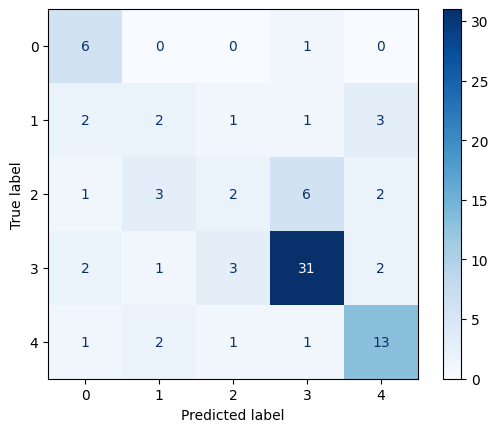

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n")
print("STD test scote:", grid.cv_results_["std_test_score"].mean()) # Model Stability
print("\n")

print("Accuracy:", accuracy_score(y_test, y_pred)) # Accuracy
print("\n")

print("MAE:", mean_absolute_error(y_test, y_pred)) # Average distance between predicted and true class labels
print("\n")

print("Classification Report: \n")
print(classification_report(y_test, y_pred))
print("\n")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3, 4]
)

disp.plot(cmap="Blues", values_format="d")
plt.show()

## Model Performance Analysis

Although the model achieves an overall **accuracy of 62%**, the class-wise results reveal an imbalanced performance.  
Classes **1** and **2** are poorly predicted, while **class 3** dominates the classification results. This indicates that the model performs well on **frequent and extreme severity classes**, but struggles to discriminate **minority and intermediate severity levels**.

The model reports a **cross-validation standard deviation of 4.6%**, which suggests **high stability** across folds. This indicates that the model’s performance is consistent and not overly sensitive to how the data is split.

While accuracy provides a general performance overview, it is **not sufficient on its own** for evaluating this task due to class imbalance and the ordinal nature of the labels. For this reason, **Mean Absolute Error (MAE)** is also considered.  
The model achieves an **MAE of 0.67**, meaning that predictions deviate by **less than one severity level on average**. This is a strong result for **ordinal classification** and aligns closely with the observed confusion matrix.

The confusion matrix shows that most misclassifications occur between **neighbouring severity levels**, indicating that the model largely preserves the **ordinal structure** of the problem, despite reduced discrimination for minority intermediate classes.

### Precision, Recall, and F1-Score Summary

- **Precision** is high for class 3, indicating that predictions for this dominant class are usually correct.
- **Recall** is low for classes 1 and 2, meaning the model frequently fails to identify these classes correctly.
- **F1-scores** reflect this imbalance, with strong performance on frequent classes and weaker performance on minority classes.

Overall, these metrics confirm that the model is **biased towards frequent severity levels**, but still maintains meaningful ordinal consistency.


# References

### https://scikit-learn.org/stable/modules/svm.html[1] <br> https://pubmed.ncbi.nlm.nih.gov/28606174/[2] <br> M. Abdel-Aty, "Using support vector machine models for crash injury severity analysis," Accident Analysis & Prevention, vol. 45, pp. 478–486, Mar. 2012, doi: 10.1016/j.aap.2011.08.016.[3]
